# Data Science bootcamp
В данном ноутбуке представлено решение контеста на отбор [`Data Science bootcamp`](https://start.avito.ru/datascience-bootcamp) по направлению [`classic ml`](https://stepik.org/lesson/2589118/step/1).

## Участник
**Бондаренко Федор Алексеевич** (fedobondarenko@gmail.com, [GitHub](https://github.com/FedorProgrammer), [stepik](https://stepik.org/users/189216442/profile))

# TODO
- Проверить:
    - выбросы
- Переписать функцию `get_dropped_events` -- избавиться от повторов с `split_events`
- Заполнить координаты курсора для телефонов (хотя бы (0, 0) поставить)
- Выделить структруные пропуски (`search` при `search_result_view`/`item` при `login`...)

# Оглавление:
- [Подготовка окружения](#env)
    - [Скачивание зависимостей](#deps)
    - [Конфигурация](#config)
        - [Импорты](#imports)
        - [Параметры обучения](#params)
    - [Воспроизводимость](#repro)
- [Обработка данных](#data)
    - [Загрузка данных](#load)
    - [Примеры данных](#examples)
    - [Сплит ивентов](#split)
        - [Проверка отброшенных ивентов](#leakage-check)
    - [EDA](#eda)
        - [Типы данных](#types)
        - [Пропуски в данных](#missing)
            - [Координаты курсора](#pointers)
            - [Поисковый запрос](#search)
            - [Данные item'а](#item-data)
                - [Совместно с `event_name`](#with-event-name)
        - [Проверка на "холодный старт"](#cold-start)
        - [Распределение баланса классов](#balance-dist)
            - [На train выборке](#train-balance)
            - [На events выборке](#events-balance)
                - [Без нормировки](#no-norm)
                - [log-шкала](#log-scale)
        - [Временное распределение](#time-dist)
        - [Распределение платформы](#platform-dist)
        - [Распределение событий](#events-dist)
        - [Интенсивность событий](#intensity)
- [Валидация](#validation)
- [Бейзлайн](#baseline)

# Подготовка окружения <a id="env"></a>

### Скачивание зависимостей <a id="deps"></a>
Устанавливаем необходимые файлы:
1. датасет (трейн, тест, события);
2. модуль `metric.py`;
3. пример решения.

> В дальнейшем, данные для обучения будут браться из директории `data/`.

In [1]:
import zipfile
import urllib.request
from pathlib import Path

def download_challenge_data() -> None:
    '''Устанавливает данные по ссылке, что была опубликована на странице контеста
    '''
    data_path = Path("data")
    if not data_path.is_dir():
        zip_path = Path("challenge_data.zip")
        url = "https://stepik.org/media/attachments/lesson/2589118/bot_detection_challenge.zip"
        urllib.request.urlretrieve(url, zip_path)
        
        with zipfile.ZipFile(zip_path) as challenge_zip:
            challenge_zip.extractall(path=".")
        zip_path.unlink()
        print('Данные успешно установлены')
    else:
        print("Данные уже установлены")

download_challenge_data()

Данные уже установлены


## Конфигурация <a id="config"></a>

### Импорты <a id="imports"></a>
Подключаем все необходимые библиотеки для: 
- обработки данных;
- обучения модели;
- оценки ее качества;
- визуализации.

In [2]:
import random

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import sklearn

import catboost as cb
import lightgbm as lgb

from metric import precision_at_recall

%matplotlib inline

### Параметры обучения <a id="params"></a>
Задаем основные параметры обучения

In [3]:
SEED = 42

N_SPLITS = 4
ITERATIONS = 1500

## Воспроизводимость <a id="repro"></a>
Делаем обучение воспроизводимым -- фиксируем сиды.

In [4]:
def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

set_global_seed(SEED)
print(f"Глобальный сид установлен; его значение == {SEED}")

Глобальный сид установлен; его значение == 42


# Обработка данных <a id="data"></a>

## Загрузка данных <a id="load"></a>

In [5]:
train = pd.read_csv("data/train.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
test = pd.read_csv("data/test.csv", parse_dates=['cookie_created_at', 'window_start_ts', 'window_end_ts'])
events = pd.read_csv("data/events.csv.gz", parse_dates=['event_ts'])

print(train.shape, test.shape, events.shape)

(11091, 5) (4909, 4) (328905, 14)


## Примеры данных <a id="examples"></a>

In [6]:
train.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
1891,ck_8df0e1700243310f,2026-04-07 07:17:48,2026-04-08,2026-04-09,0
9165,ck_4d70e8e03b078415,2026-02-24 18:14:14,2026-04-17,2026-04-18,0
3902,ck_eebaaa38fb01fa72,2026-01-19 04:48:21,2026-04-10,2026-04-11,0
10213,ck_1388b91f875a4fe2,2025-10-25 21:40:01,2026-04-18,2026-04-19,0
883,ck_d6cd2e957f758107,2026-03-08 14:25:06,2026-04-07,2026-04-08,0


In [7]:
test.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts
861,ck_962e65ab33b5c311,2026-04-18 17:27:47,2026-04-21,2026-04-22
2974,ck_501dcf1ead036d2b,2026-03-08 23:07:09,2026-04-24,2026-04-25
3963,ck_68250033717cd59e,2026-03-01 09:48:41,2026-04-25,2026-04-26
1774,ck_e914974cee1bccb1,2026-04-20 05:01:29,2026-04-22,2026-04-23
4360,ck_64eefec062592c43,2026-02-15 04:53:36,2026-04-26,2026-04-27


In [8]:
events.sample(5)

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
72257,ck_d026b2dc7227d214,2026-04-07 17:27:59,210,photo_swipe,WEB,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,1034301.0,zhivotnye,moskva,pro,NaN,NaN,NaN,NaN
150048,ck_e1a21ba313896b9b,2026-04-08 01:47:31,100,search_results_view,Web,Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...,NaN,mebel,novosibirsk,NaN,кровать 160х200,1.0,NaN,NaN
294032,ck_16c9b12c2561cab9,2026-04-17 23:53:28,301,contact_chat_open,Android,Mozilla/5.0 (Linux; Android 12; SM-A515F) Appl...,1021852.0,telefony,cheboksary,pro,NaN,NaN,NaN,NaN
157557,ck_9e84edadcce8c071,2026-04-08 11:53:26,400,favorite_add,ANDROID,Mozilla/5.0 (Linux; Android 14; Pixel 6) Apple...,1051814.0,bytovaya_tehnika,moskva,private,NaN,NaN,NaN,NaN
279786,ck_f409ff994a210601,2026-04-25 17:37:27,200,item_view,Android,Mozilla/5.0 (Linux; Android 12; Pixel 6) Apple...,1034262.0,hobbi,ekaterinburg,private,NaN,NaN,NaN,NaN


### Нормализация `events[platform]` <a id='normalizing'></a>
Множество платформ-синонимов может вносить дополнительный шум -- объединим похожие.

In [9]:
events['platform'].value_counts()

platform
desktop    46866
WEB        46476
Web        46365
web        45951
ANDROID    42462
Android    42254
android    42159
iphone      4103
IOS         4100
iOS         4091
ios         4078
Name: count, dtype: int64

In [10]:
events['platform'] = events['platform'].replace(['WEB', 'Web', 'web'], 'WEB')
events['platform'] = events['platform'].replace(['ANDROID', 'Android', 'android'], 'ANDROID')
events['platform'] = events['platform'].replace(['iphone', 'IOS', 'iOS', 'ios'], 'IOS')

events['platform'].value_counts()

platform
WEB        138792
ANDROID    126875
desktop     46866
IOS         16372
Name: count, dtype: int64

## Сплит ивентов <a id="split"></a>

In [11]:
def split_events(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    '''Функция для добавления мета-данных куки
    '''
    meta_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']
    ev = events.merge(meta[meta_columns], on='cookie_id', how='right')
    
    mask = (ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts'])
    return ev[mask]

events_tr = split_events(events, train)
events_tr_labeled = events_tr.merge(train[['cookie_id', 'target']], on='cookie_id')

events_te = split_events(events, test)

events.shape, events_tr.shape, events_te.shape

((328905, 14), (198436, 16), (89690, 16))

**Наблюдение:** из датафрейма `events` пропало ~40_000 объектов. Скорее всего это дело временной маски.

### Проверка отброшенных ивентов <a id="leakage-check"></a>
Если отброшенные события произошли после окна события, то при их использовании (например, для заполнения пропусков) возможна утечка.  
Проверим это:

In [12]:
def get_dropped_events(events: pd.DataFrame, meta: pd.DataFrame) -> pd.DataFrame:
    '''Да, повтор функции split_events...
    '''
    meta_columns = ['cookie_id', 'window_start_ts', 'window_end_ts']
    ev = events.merge(meta[meta_columns], on='cookie_id', how='right')

    mask = ~((ev['event_ts'] >= ev['window_start_ts']) & (ev['event_ts'] < ev['window_end_ts']))
    return ev[mask]

dropped_tr = get_dropped_events(events, train)
dropped_te = get_dropped_events(events, test)

dropped_tr.shape, dropped_te.shape

((40779, 16), (0, 16))

In [13]:
before = dropped_tr[dropped_tr['event_ts'] < dropped_tr['window_start_ts']]
after = dropped_tr[dropped_tr['event_ts'] >= dropped_tr['window_end_ts']]

print(f"Отброшенные до окна: {len(before)}, отброшенные после окна: {len(after)}")

Отброшенные до окна: 0, отброшенные после окна: 40779


**Наблюдение:** все отброшенные ивенты произошли после окна -- их использования при агрегации может привести к утечке данных.

## EDA <a id="eda"></a>

### Типы данных <a id="types"></a>

In [14]:
train.dtypes

cookie_id                       str
cookie_created_at    datetime64[us]
window_start_ts      datetime64[us]
window_end_ts        datetime64[us]
target                        int64
dtype: object

In [15]:
events.dtypes

cookie_id                   str
event_ts         datetime64[us]
eid                       int64
event_name                  str
platform                    str
user_agent                  str
item_id                 float64
item_category               str
item_location               str
seller_type                 str
search_query                str
search_page             float64
pointer_x               float64
pointer_y               float64
dtype: object

### Пропуски в данных <a id="missing"></a>

In [16]:
train.isna().mean().round(3)

cookie_id            0.0
cookie_created_at    0.0
window_start_ts      0.0
window_end_ts        0.0
target               0.0
dtype: float64

In [17]:
events.isna().mean().round(3)

cookie_id        0.000
event_ts         0.000
eid              0.000
event_name       0.000
platform         0.000
user_agent       0.000
item_id          0.348
item_category    0.100
item_location    0.072
seller_type      0.407
search_query     0.695
search_page      0.695
pointer_x        0.670
pointer_y        0.670
dtype: float64

In [18]:
events_tr.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.331
item_category      0.079
item_location      0.050
seller_type        0.391
search_query       0.689
search_page        0.689
pointer_x          0.666
pointer_y          0.666
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

In [19]:
events_te.isna().mean().round(3)

cookie_id          0.000
event_ts           0.000
eid                0.000
event_name         0.000
platform           0.000
user_agent         0.000
item_id            0.333
item_category      0.076
item_location      0.050
seller_type        0.392
search_query       0.687
search_page        0.687
pointer_x          0.672
pointer_y          0.672
window_start_ts    0.000
window_end_ts      0.000
dtype: float64

**Наблюдения:**
- Подозреваю, что большая часть ивентов делается ботами --> отсутствуют координаты курсора?
- Большое количество пропусков курсора может зависить от платформы?
- Пропуски разбились в равных пропорциях (для `events_tr` и `events_te`).

#### Координаты курсора <a id="pointers"></a>

In [20]:
events_tr_labeled.pivot_table(
    index='target', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,pointer_x,pointer_y
target,,
human,0.653,0.653
bot,0.754,0.754


In [21]:
events_tr_labeled.pivot_table(
    index='platform', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,pointer_x,pointer_y
platform,,
ANDROID,1.000,1.000
IOS,1.000,1.000
WEB,0.398,0.398
desktop,0.398,0.398


In [22]:
mask = (events_tr_labeled['platform'].isin(['WEB', 'desktop']))
cursor_cm = events_tr_labeled[mask].pivot_table(
    index='target', columns='platform', values=['pointer_x', 'pointer_y'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

cursor_cm = cursor_cm['pointer_x'] # pointer_x и pointer_y и так одинкаковы
cursor_cm.columns.name = 'pointers'
cursor_cm

pointers,WEB,desktop
target,,
human,0.338,0.338
bot,0.669,0.673


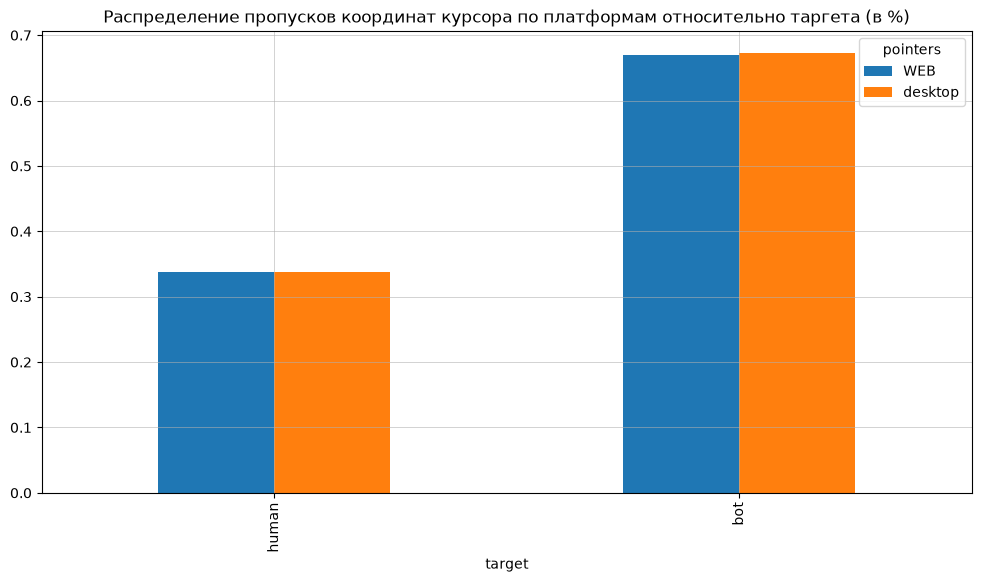

In [23]:
cursor_cm.plot(kind='bar', figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Распределение пропусков координат курсора по платформам относительно таргета (в %)")
plt.show()

**Наблюдения:**
- Пропуски курсора напрямую зависят от платформы;
- Больше пропусков курсоров у ботов, причем на платформах `WEB` и `desktop`, их **в 2 раза больше** у ботов;
- "Частичных" пропусков координат (пропуск одной из) не наблюдается.

Пропуск координаты курсора -- явный признак.  
Для платформ `ANDROID` и `IOS` следует их заполнить какими-то данными (хотя бы (0, 0)), чтобы модель могла определить реальный пропуск от отсутствия курсора.

#### Поисковый запрос <a id="search"></a>

In [24]:
events_tr_labeled.pivot_table(
    index='target', values=['search_query', 'search_page'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,search_page,search_query
target,,
human,0.695,0.695
bot,0.648,0.648


In [25]:
events_tr_labeled.pivot_table(
    index='event_name', values=['search_query', 'search_page'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,search_page,search_query
event_name,,
contact_chat_open,1.0,1.0
contact_message_sent,1.0,1.0
contact_phone_show,1.0,1.0
favorite_add,1.0,1.0
item_view,1.0,1.0
login,1.0,1.0
photo_swipe,1.0,1.0
search_results_view,0.0,0.0
seller_page_view,1.0,1.0


**Наблюдение:** пропуск у `search_page`/`search_query` строго структрен -- пропуск полностью объясняется типом события.

#### Данные item'а <a id="item-data"></a>

In [26]:
events_tr_labeled.pivot_table(
    index='target', values=['item_id', 'item_category', 'item_location', 'seller_type'],
    aggfunc=lambda x: x.isna().mean().round(3)
).rename(index={0:'human', 1:'bot'})

,item_category,item_id,item_location,seller_type
target,,,,
human,0.080,0.326,0.051,0.388
bot,0.069,0.359,0.038,0.416


In [27]:
events_tr_labeled[['seller_type']].value_counts()

seller_type
private        69729
pro            51049
Name: count, dtype: int64

In [28]:
events_tr_labeled['seller_type'].unique()

<StringArray>
['pro', nan, 'private']
Length: 3, dtype: str

**Наблюдения:**
- Дисбаланса почти нет -- оба таргета имеют примерно те же значения пропусков
- Пропуски по `seller_type` могут сигнализировать о "стандартном" типе продавца, а не об отсутствие данных по этому полю как такового (последнее может коррелировать со "спец" ивентами (логин, ...)).

С учетом, что это скорей служебная информация (сложная для агрегатного заполнения), возможно, следует: 
1. отбросить строки с пропусками (для `item_category`, `item_location`)
2. дать `catboost` самому их заполнить

##### Совместно с `event_name` <a id="with-event-name"></a>
Проверим, как часто данные item'а принимают `NaN` по отношению к различным событиям.  
Это может дать ответ на следующие вопросы:
1. Может ли являться `NaN` -- дефолтным значением для `seller_type` (когда у продавца нету `pro`, но профиль не закрыт (`private`))?
2. Что происходит в полях данных айтема при спец ивентах (`login`, ...)?

In [29]:
events_tr_labeled.pivot_table(
    index='event_name', values=['item_id', 'item_category', 'item_location', 'seller_type'],
    aggfunc=lambda x: x.isna().mean().round(3)
)

,item_category,item_id,item_location,seller_type
event_name,,,,
contact_chat_open,0.060,0.0,0.032,0.086
contact_message_sent,0.062,0.0,0.031,0.095
contact_phone_show,0.061,0.0,0.029,0.093
favorite_add,0.062,0.0,0.028,0.093
item_view,0.060,0.0,0.030,0.091
login,1.000,1.0,1.000,1.000
photo_swipe,0.058,0.0,0.032,0.089
search_results_view,0.061,1.0,0.031,1.000
seller_page_view,0.059,0.0,0.032,0.091


**Наблюдения:**
- `item_id` по сути всегда заполнен -- его не хватает только на "общих планах"
- `seller_type`==`NaN` действительно может быть дефолтом (при заполненном `item_id` есть объекты с `seller_type` == `NaN`)

Стоит выделить отдельную переменную для более наглядной регистрации ивента `login` -- чтобы модель не путала пропуски при `login` с другими

### Проверка на "холодный старт" <a id="cold-start"></a>
Проверка на куки, что не имеют **за период событий ни одного события** (*"холодный старт"* относительно признаков из `events`)

In [30]:
def check_cold_start(split: pd.DataFrame, event_split: pd.DataFrame) -> set:
    '''Проверка на то, что все куки из split имеют хотя бы одно событие в event_split
    '''
    split_unique = set(split['cookie_id'].unique())
    event_split_unique = set(event_split['cookie_id'].unique())

    return split_unique - event_split_unique

In [31]:
check_cold_start(train, events_tr), check_cold_start(events_tr, train)

(set(), set())

In [32]:
check_cold_start(test, events_te), check_cold_start(events_te, test)

(set(), set())

**Наблюдения:** 
- Холодного старта (кук без единого события в окне) нет;
- И наоборот, лишних кук (что отсутствуют в трейне/тесте, но есть в ивентах) тоже нет.

### Распределение баланса классов <a id="balance-dist"></a>

#### На `train`-выборке <a id="train-balance"></a>

In [33]:
def get_class_balance(df: pd.DataFrame) -> pd.Series:
    '''Обертка над value_counts (с переименованием индекса)
    '''
    return df['target'].value_counts().rename(index={0:'human', 1:'bot'})

In [34]:
train_cls_b = get_class_balance(train)
train_cls_b

target
human    10192
bot        899
Name: count, dtype: int64

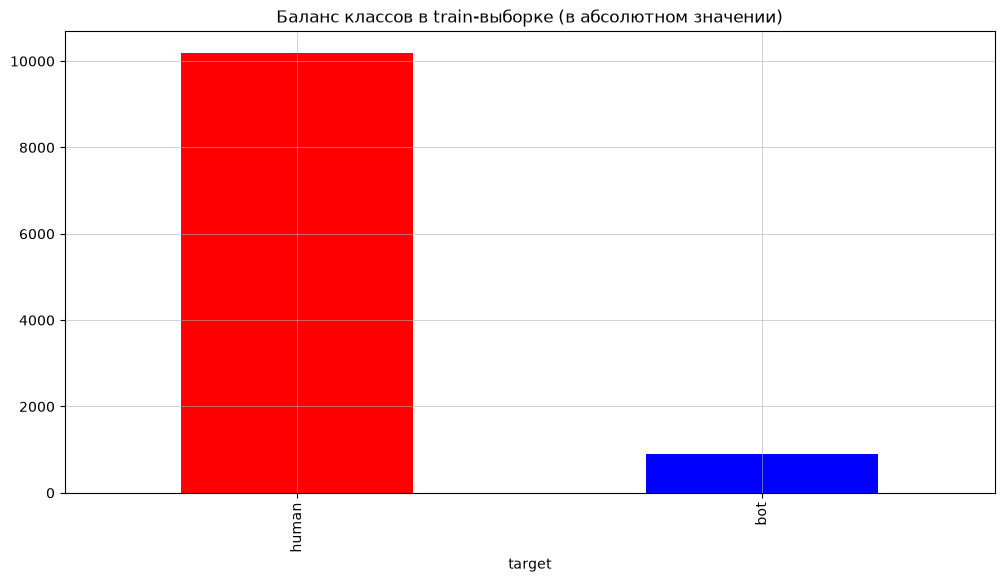

In [35]:
train_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в train-выборке (в абсолютном значении)")
plt.show()

`Train`-выборка имеет четко выраженный дисбаланс в пользу `human`.

#### На `events`-выборке <a id="events-balance"></a>

##### Без нормировки <a id="no-norm"></a>

In [36]:
events_tr_cls_b = get_class_balance(events_tr_labeled)
events_tr_cls_b

target
human    171929
bot       26507
Name: count, dtype: int64

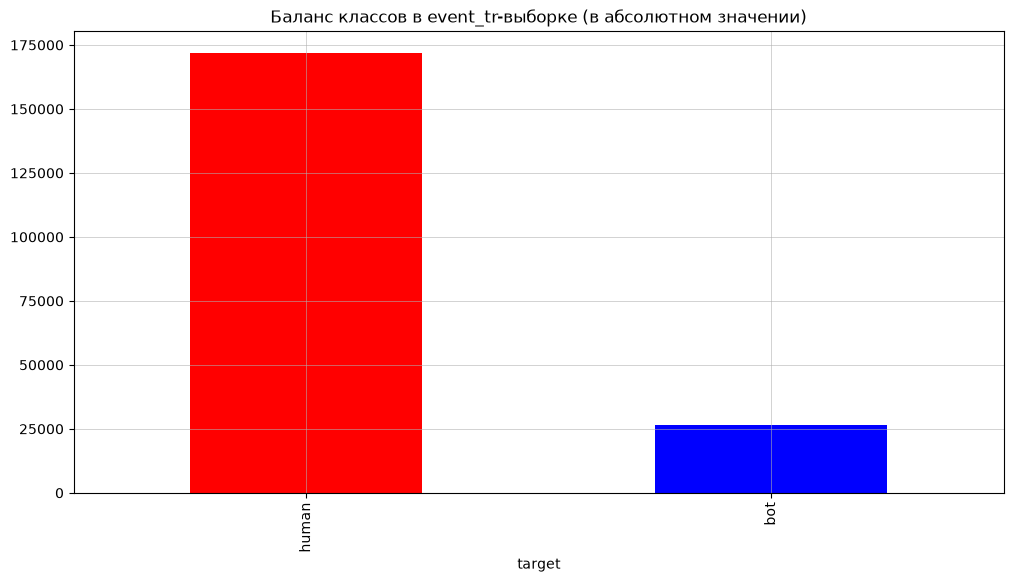

In [37]:
events_tr_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в event_tr-выборке (в абсолютном значении)")
plt.show()

**Наблюдения:**
- Сильный байес в пользу людей
- Возможно боты и создают ивентов интенсивнее --> попробуем отнормировать

##### log-шкала <a id="log-scale"></a>

In [38]:
log_events_tr_cls_b = np.log(events_tr_cls_b)
log_events_tr_cls_b

target
human    12.054837
bot      10.185164
Name: count, dtype: float64

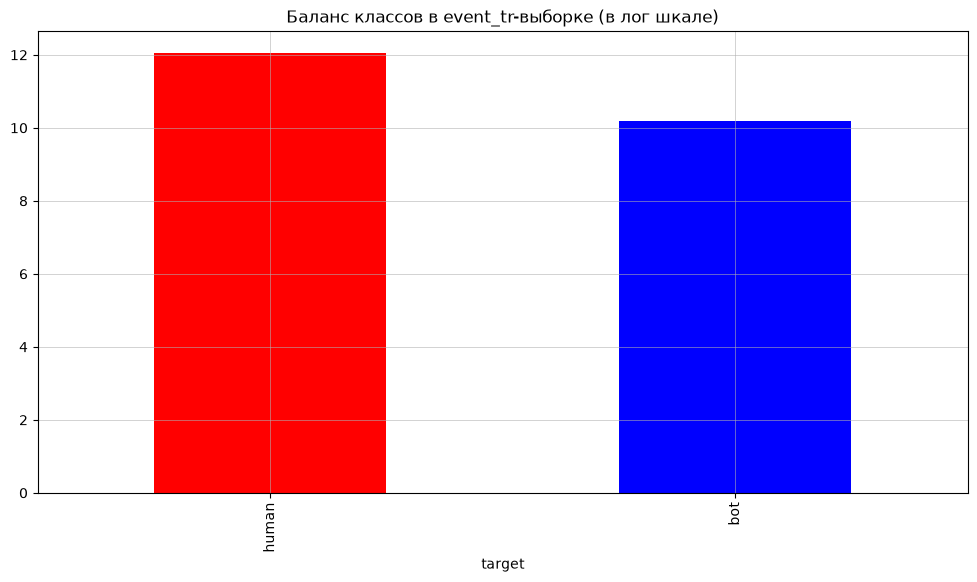

In [39]:
log_events_tr_cls_b.plot(kind='bar', color=['red', 'blue'], figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Баланс классов в event_tr-выборке (в лог шкале)")
plt.show()

### Временное распределение <a id="time-dist"></a>
Проверка распределения времени:
1. Распределение времени существования кук до их окна (боты могут раньше начать активничать)
2. Распределение создания кук по часам/дням
3. Распределение длительности ивентов

In [40]:
time_tr = train.assign(cookie_age_days=(train['window_start_ts'] - train['cookie_created_at']).dt.days)
time_tr['cookie_created_hr'] = train['cookie_created_at'].dt.hour
time_tr['cookie_created_dow'] = train['cookie_created_at'].dt.day_name()

time_tr.sample(5)

,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target,cookie_age_days,cookie_created_hr,cookie_created_dow
5667,ck_b679bf1187328e01,2025-12-16 04:05:17,2026-04-12,2026-04-13,0,116,4,Tuesday
9522,ck_308d37633d0a48ba,2026-04-14 05:44:20,2026-04-17,2026-04-18,0,2,5,Tuesday
5322,ck_ba030a508b6641b7,2025-11-30 02:20:17,2026-04-12,2026-04-13,0,132,2,Sunday
6654,ck_a685818756784fa4,2025-12-24 03:57:43,2026-04-13,2026-04-14,0,109,3,Wednesday
8125,ck_7ad52944a8be8b3d,2026-01-31 19:26:55,2026-04-15,2026-04-16,0,73,19,Saturday


In [41]:
time_tr.groupby('target')['cookie_age_days'].describe().rename(index={0:'human', 1:'bot'})

,count,mean,std,min,25%,50%,75%,max
target,,,,,,,,
human,10192.0,73.415718,66.959727,0.0,18.0,61.0,110.0,449.0
bot,899.0,48.241379,62.785407,0.0,0.0,18.0,83.0,361.0


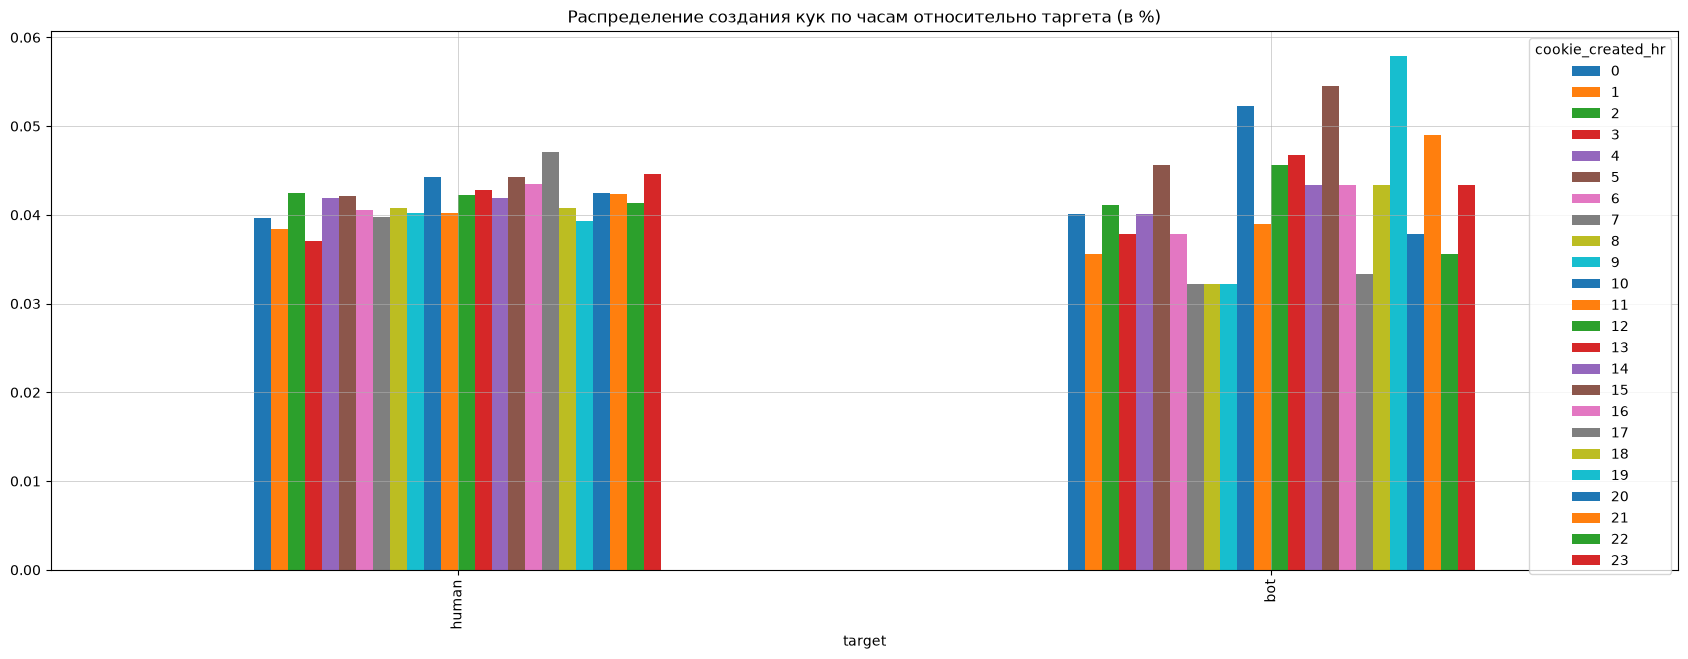

In [42]:
cookie_hr_dist = pd.crosstab(
    index=time_tr['target'], columns=time_tr['cookie_created_hr'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})

cookie_hr_dist.plot(kind='bar', figsize=(21, 7))
plt.grid(True, linewidth=0.4)
plt.title("Распределение создания кук по часам относительно таргета (в %)")
plt.show()

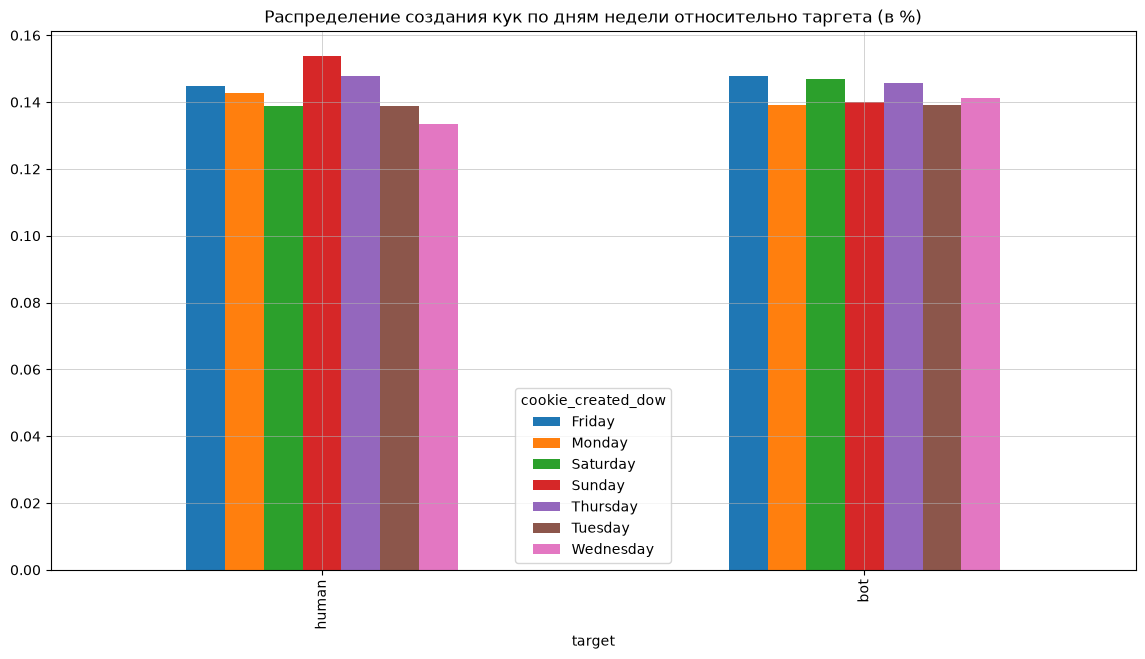

In [43]:
cookie_dow_dist = pd.crosstab(
    index=time_tr['target'], columns=time_tr['cookie_created_dow'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})

cookie_dow_dist.plot(kind='bar', figsize=(14, 7))
plt.grid(True, linewidth=0.4)
plt.title("Распределение создания кук по дням недели относительно таргета (в %)")
plt.show()

**Наблюдения:**
- В среднем куки человека "живет" до окна дольше в ~1.5 раза;
- По медиане разрыв `cookie_age_days` в ~3 раза в пользу людей -- куки людей дольше "бездействуют";
- У каждого 4го бота кука создана в тот же день, что и окно наблюдения;
- Распределения создания кук по часам у людей более равномерное 

### Распределение платформы <a id="platform-dist"></a>
Проверка баланса классов по платформе.

In [44]:
platform_target_cls_b = pd.crosstab(
    index=events_tr_labeled['target'], columns=events_tr_labeled['platform'],
    normalize='index'
).round(3).rename({0:'human', 1:'bot'})
platform_target_cls_b

platform,ANDROID,IOS,WEB,desktop
target,,,,
human,0.418,0.057,0.392,0.133
bot,0.234,0.021,0.556,0.189


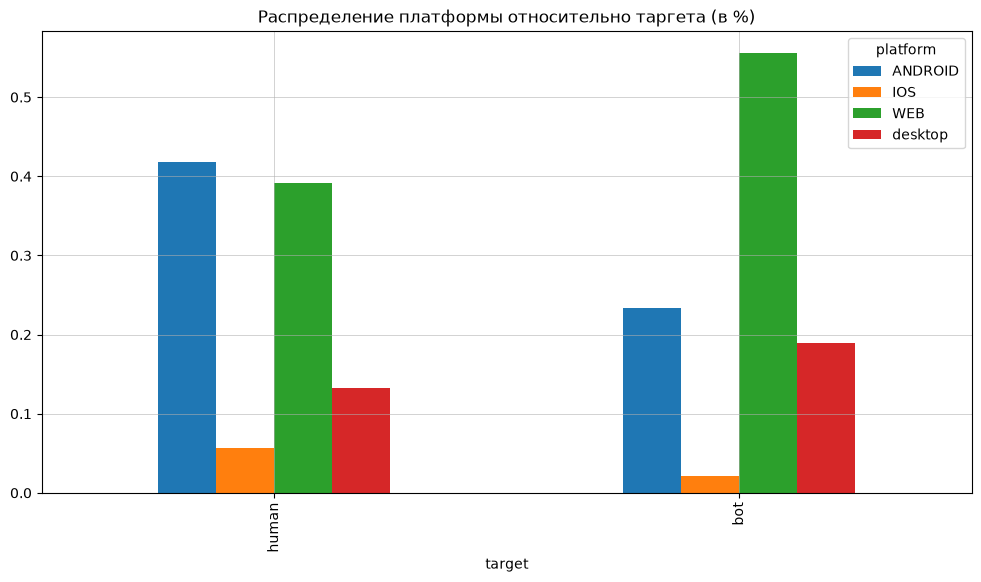

In [45]:
platform_target_cls_b.plot(kind='bar', figsize=(12, 6))
plt.grid(True, linewidth=0.4)
plt.title("Распределение платформы относительно таргета (в %)")
plt.show()

**Наблюдение:** боты в основном сидят на `WEB` платформе.

### Распределение событий <a id="events-dist"></a>
Посмотрим, какие события обычно соответствуют какому таргету.

In [46]:
events_cls_b = pd.crosstab(
    index=events_tr_labeled['target'], columns=events_tr_labeled['event_name'],
    normalize='index'
).rename(index={0:'human', 1:'bot'})
events_cls_b

event_name,contact_chat_open,contact_message_sent,contact_phone_show,favorite_add,item_view,login,photo_swipe,search_results_view,seller_page_view
target,,,,,,,,,
human,0.019799,0.010289,0.036998,0.065824,0.365093,0.021480,0.122673,0.304771,0.053074
bot,0.014185,0.007922,0.025842,0.027163,0.436413,0.007809,0.070170,0.351530,0.058966


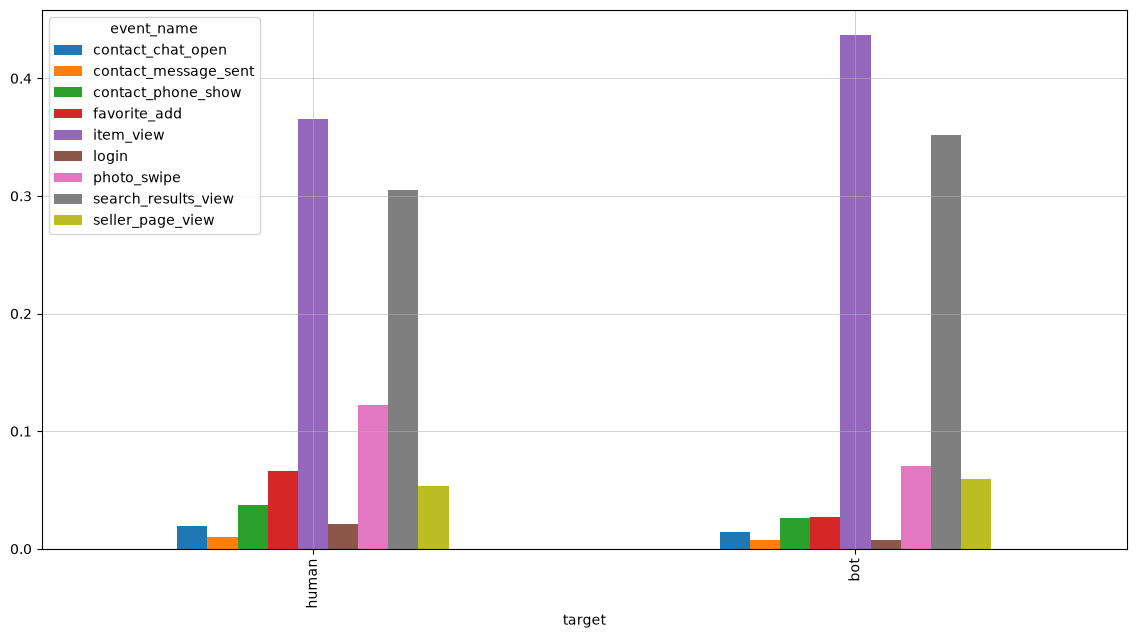

In [47]:
events_cls_b.plot(kind='bar', figsize=(14, 7))
plt.grid(True, linewidth=0.4)
plt.show()

**Наблюдение:** распределения совпадают. Ярковыраженного сигнала нет.

### Интенсивность событий <a id="intensity"></a>

Проверка среднего количество событий на куку -- хоть и дисбаланс классов присутствует, но боты могут интесивнее генерируют запросы

In [48]:
events_per_cookie = events_tr_labeled.groupby(['cookie_id', 'target']).size().rename('n_events').reset_index() # чтобы оставить target, пришлось делать и по нему группировку
avg_events_per_cookie_cls_b = events_per_cookie.groupby('target')['n_events'].mean().rename(index={0:'human', 1:'bot'})
avg_events_per_cookie_cls_b

target
human    16.869015
bot      29.484983
Name: n_events, dtype: float64

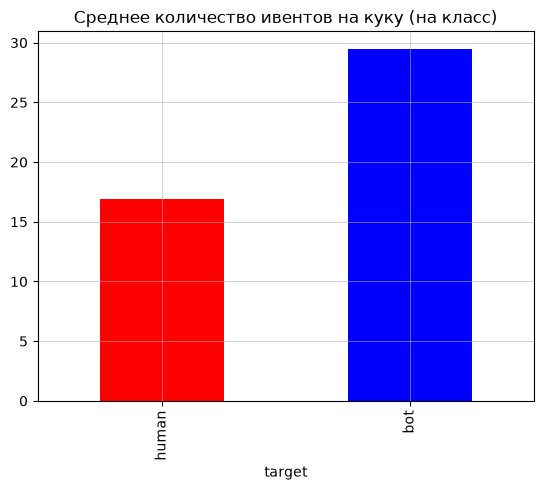

In [49]:
avg_events_per_cookie_cls_b.plot(kind='bar', color=['red', 'blue'])
plt.grid(True, linewidth=0.4)
plt.title("Среднее количество ивентов на куку (на класс)")
plt.show()

Нормировка помогла (относительно сущности) -- боты действительно генерируют больше событий (~в 2 раза больше)

# Валидация <a id="validation"></a>

Наблюдения:
1. Необходимо соблюдать time-based сплит (из-за возможной утечки данных, в противном случае)
2. Из-за большого дисбаланса классов лучше построить сплит с расширяемым окном (иначе шумит оценка $P@R_{\ge{0.7}}$)

In [50]:
def build_time_blocks_cv(train: pd.DataFrame, n_splits: int) -> tuple[pd.Series, pd.Series]:
    '''Функция для построения валидации -- расширяемое окно на основе time-based сплита
    Проводит ленивое вычисление
    '''
    dates = np.sort(train['window_start_ts'].unique())
    blocks = np.array_split(dates, n_splits+1) #! у np.split мб ValueError из-за нецелого разбиения

    for i in range(1, n_splits + 1):
        val_mask = blocks[i]
        val_ts = train['window_start_ts'].isin(val_mask)
        train_ts = train['window_start_ts'].isin(np.concatenate(blocks[:i]))

        yield train_ts, val_ts   

In [51]:
def build_train_loop(X_train: pd.DataFrame, y_train: pd.Series, cv_split: tuple[pd.Series, pd.Series], features: list[str]) -> list[float]:
    '''Вынос логики обучения с cv в отдельную функцию
    Возвращает скоры модели по всем фолдам
    '''
    scores = []
    for idx, (train_ts, val_ts) in enumerate(cv_split):
        cbm = cb.CatBoostClassifier(
            random_state=SEED,
            iterations=ITERATIONS,
            verbose=False
        )

        cbm.fit(X_train.loc[train_ts, features], y_train[train_ts])
        proba = cbm.predict_proba(X_train.loc[val_ts, features])[:, 1]
        score = precision_at_recall(y_train[val_ts], proba)
        scores.append(score)

        print('-'*10)
        print(f"SPLIT#{idx}")
        print(f"\tsize_tr={train_ts.sum()}, size_val={val_ts.sum()}")
        print(f"\tn_bots_tr={y_train[train_ts].sum()}, n_bots_val={y_train[val_ts].sum()}")
        print(f"score={score:.4f}")

    return scores

# Бейзлайн <a id="baseline"></a>

За основу взял `catboost` -- из-за быстрой обработки пропусков и категориальных фич.

In [52]:
def build_baseline_features(event_split: pd.DataFrame, split: pd.DataFrame) -> pd.DataFrame:
    '''Строит минимальный набор фич (для бейзлайна)
    '''
    event_split = event_split.groupby('cookie_id').agg(
        n_events = ('cookie_id', 'size'),
        n_unique_items = ('item_id', 'nunique')
    )
    return split[['cookie_id']].merge(event_split.reset_index(), on='cookie_id', how='left').fillna(0)

In [53]:
X_train = build_baseline_features(events_tr, train)
X_test = build_baseline_features(events_te, test)
y_train = train['target'].values

features_bl = ['n_events', 'n_unique_items']

X_train.shape, y_train.shape, X_test.shape

((11091, 3), (11091,), (4909, 3))

In [54]:
scores_bl = build_train_loop(
    X_train, y_train, 
    build_time_blocks_cv(train, N_SPLITS),
    features_bl
)

print('-'*10)
print(f"score.mean={np.mean(scores_bl):.4f}, score.std={np.std(scores_bl):.4f}")

----------
SPLIT#0
	size_tr=2403, size_val=2710
	n_bots_tr=197, n_bots_val=227
score=0.1092
----------
SPLIT#1
	size_tr=5113, size_val=2486
	n_bots_tr=424, n_bots_val=190
score=0.1106
----------
SPLIT#2
	size_tr=7599, size_val=2254
	n_bots_tr=614, n_bots_val=191
score=0.1365
----------
SPLIT#3
	size_tr=9853, size_val=1238
	n_bots_tr=805, n_bots_val=94
score=0.1053
----------
score.mean=0.1154, score.std=0.0123


In [55]:
model_cb = cb.CatBoostClassifier(
    random_state=SEED,
    iterations=ITERATIONS,
    verbose=100
)

model_cb.fit(X_train[features_bl], y_train)

Learning rate set to 0.019845
0:	learn: 0.6714247	total: 5.55ms	remaining: 8.32s
100:	learn: 0.2623387	total: 207ms	remaining: 2.87s
200:	learn: 0.2538578	total: 401ms	remaining: 2.59s
300:	learn: 0.2511704	total: 610ms	remaining: 2.43s
400:	learn: 0.2494182	total: 811ms	remaining: 2.22s
500:	learn: 0.2477337	total: 1.02s	remaining: 2.03s
600:	learn: 0.2457728	total: 1.22s	remaining: 1.82s
700:	learn: 0.2441700	total: 1.41s	remaining: 1.61s
800:	learn: 0.2427665	total: 1.61s	remaining: 1.41s
900:	learn: 0.2413672	total: 1.81s	remaining: 1.2s
1000:	learn: 0.2400195	total: 2.02s	remaining: 1s
1100:	learn: 0.2390307	total: 2.22s	remaining: 804ms
1200:	learn: 0.2380319	total: 2.42s	remaining: 601ms
1300:	learn: 0.2370464	total: 2.61s	remaining: 400ms
1400:	learn: 0.2362221	total: 2.81s	remaining: 199ms
1499:	learn: 0.2353711	total: 3.03s	remaining: 0us


CatBoostClassifier(iterations=1500, random_state=42, verbose=100)

In [56]:
sub = pd.DataFrame({
    'cookie_id': X_test['cookie_id'],
    'score': model_cb.predict_proba(X_test[features_bl])[:, 1],
})

assert len(sub) == len(test) and sub['score'].between(0, 1).all()

sub.to_csv('submission.csv', index=False)
sub.head()

,cookie_id,score
0,ck_315fb710a0e371e7,0.024513
1,ck_a76ee3b3e3e522fd,0.056277
2,ck_94c9a4d382689e82,0.059816
3,ck_8eaf9509ad9462a0,0.056277
4,ck_9a88a5a989cb5bc6,0.027737
